# Principal Component Analysis (PCA) from Scratch

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook implements Principal Component Analysis (PCA) from scratch using NumPy, without relying on scikit‑learn's PCA implementation. We manually compute the covariance matrix, perform eigendecomposition, project data onto principal components, and visualise the results. This provides a deep understanding of how PCA works internally.

**Key techniques & libraries:**
- NumPy – matrix operations, eigendecomposition
- Pandas – data manipulation
- Matplotlib – publication‑quality visualisations
- Custom PCA implementation – centering, standardisation, covariance, eigendecomposition, projection

**Data source:**  
Synthetic dataset generated within the notebook – no external files required.

In [2]:
# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility seeds
np.random.seed(42)

# High-resolution plot settings
%config InlineBackend.figure_format = 'retina'

# Matplotlib style
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.titlesize'] = 14

In [3]:
def standardize_data(data):
    """
    Center and standardize data to have zero mean and unit variance.
    
    Args:
        data (np.ndarray): Input data matrix (n_samples x n_features).
    
    Returns:
        tuple: (data_standardized, mean, std) where mean and std are arrays.
    """
    mean = data.mean(axis=0)
    std = data.std(axis=0, ddof=1)  # sample standard deviation
    data_centered = data - mean
    data_standardized = data_centered / std
    return data_standardized, mean, std

def compute_covariance_matrix(data):
    """
    Compute the covariance matrix of the data.
    
    Args:
        data (np.ndarray): Standardized data (n_samples x n_features).
    
    Returns:
        np.ndarray: Covariance matrix (n_features x n_features).
    """
    return np.cov(data, rowvar=False)

def perform_eigendecomposition(cov_matrix):
    """
    Perform eigendecomposition on the covariance matrix.
    
    Args:
        cov_matrix (np.ndarray): Covariance matrix.
    
    Returns:
        tuple: (eigenvalues, eigenvectors) sorted in descending order of eigenvalues.
    """
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    # Sort in descending order
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

def project_data(data, eigenvectors, n_components):
    """
    Project data onto the first n_components principal components.
    
    Args:
        data (np.ndarray): Standardized data.
        eigenvectors (np.ndarray): Eigenvectors (columns are components).
        n_components (int): Number of principal components to project onto.
    
    Returns:
        np.ndarray: Projected data (n_samples x n_components).
    """
    return data @ eigenvectors[:, :n_components]

def explained_variance_ratio(eigenvalues):
    """
    Compute the proportion of variance explained by each principal component.
    
    Args:
        eigenvalues (np.ndarray): Eigenvalues in descending order.
    
    Returns:
        np.ndarray: Explained variance ratios.
    """
    return eigenvalues / eigenvalues.sum()

def plot_projection_1d(projection, title="Projection onto First Principal Component (1D)", figsize=(8, 5)):
    """
    Plot 1D projection of data onto the first principal component.
    
    Args:
        projection (np.ndarray): 1D projected values.
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    plt.scatter(projection, np.zeros_like(projection), color='green', s=50)
    for i, txt in enumerate(range(1, len(projection)+1)):
        plt.annotate(txt, (projection[i], 0), textcoords="offset points", xytext=(0, 10), ha='center')
    plt.title(title)
    plt.xlabel("First Principal Component")
    plt.yticks([])
    plt.tight_layout()
    plt.show()

def plot_projection_2d(projection, title="Projection onto First Two Principal Components (2D)", figsize=(8, 6)):
    """
    Plot 2D projection of data onto the first two principal components.
    
    Args:
        projection (np.ndarray): 2D projected values (n_samples x 2).
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    plt.scatter(projection[:, 0], projection[:, 1], color='blue', s=50)
    for i, txt in enumerate(range(1, len(projection)+1)):
        plt.annotate(txt, (projection[i, 0], projection[i, 1]), textcoords="offset points", xytext=(5, 5))
    plt.title(title)
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
# Generate synthetic dataset
data = np.array([
    [2, 0, 1, 3],
    [4, 0, 2, 6],
    [3, 1, 3, 5],
    [5, 2, 4, 8],
    [4, 1, 2, 7],
    [6, 2, 5, 9]
])

column_names = ['A', 'B', 'C', 'D']
df = pd.DataFrame(data, columns=column_names)

print("Original Data:")
display(df)
print(f"Shape: {df.shape}")
print(f"Summary statistics:\n{df.describe()}")

Original Data:


,A,B,C,D
0,2,0,1,3
1,4,0,2,6
2,3,1,3,5
3,5,2,4,8
4,4,1,2,7
5,6,2,5,9


Shape: (6, 4)
Summary statistics:
              A         B         C         D
count  6.000000  6.000000  6.000000  6.000000
mean   4.000000  1.000000  2.833333  6.333333
std    1.414214  0.894427  1.471960  2.160247
min    2.000000  0.000000  1.000000  3.000000
25%    3.250000  0.250000  2.000000  5.250000
50%    4.000000  1.000000  2.500000  6.500000
75%    4.750000  1.750000  3.750000  7.750000
max    6.000000  2.000000  5.000000  9.000000


In [5]:
# Standardise data
data_std, mean, std = standardize_data(data)
df_std = pd.DataFrame(data_std, columns=column_names)
print("Standardised Data (zero mean, unit variance):")
display(df_std)
print(f"Mean: {df_std.mean().values.round(6)}")
print(f"Std: {df_std.std(ddof=1).values.round(6)}")

Standardised Data (zero mean, unit variance):


,A,B,C,D
0,-1.414214,-1.118034,-1.245505,-1.543033
1,0.000000,-1.118034,-0.566139,-0.154303
2,-0.707107,0.000000,0.113228,-0.617213
3,0.707107,1.118034,0.792594,0.771517
4,0.000000,0.000000,-0.566139,0.308607
5,1.414214,1.118034,1.471960,1.234427


Mean: [ 0.  0. -0.  0.]
Std: [1. 1. 1. 1.]


In [6]:
# Compute covariance matrix
cov_matrix = compute_covariance_matrix(data_std)
print("Covariance Matrix:")
display(pd.DataFrame(cov_matrix, columns=column_names, index=column_names))

# Perform eigendecomposition
eigenvalues, eigenvectors = perform_eigendecomposition(cov_matrix)
print(f"Eigenvalues:\n{eigenvalues}")
print(f"Eigenvectors (columns are components):\n{eigenvectors}")

# Explained variance ratio
var_exp = explained_variance_ratio(eigenvalues)
print(f"Explained variance ratio:\n{var_exp}")
print(f"Cumulative explained variance: {np.cumsum(var_exp)}")

Covariance Matrix:


,A,B,C,D
A,1.000000,0.790569,0.864692,0.981981
B,0.790569,1.000000,0.911465,0.828079
C,0.864692,0.911465,1.000000,0.838628
D,0.981981,0.828079,0.838628,1.000000


Eigenvalues:
[3.60834503 0.29000019 0.09608052 0.00557426]
Eigenvectors (columns are components):
[[ 0.5045614   0.51104992 -0.18024273  0.6721297 ]
 [ 0.48853849 -0.60612729  0.57628608  0.24866483]
 [ 0.50068051 -0.39374492 -0.72203207 -0.27009934]
 [ 0.5060306   0.46519095  0.33775227 -0.64300374]]
Explained variance ratio:
[0.90208626 0.07250005 0.02402013 0.00139356]
Cumulative explained variance: [0.90208626 0.9745863  0.99860644 1.        ]


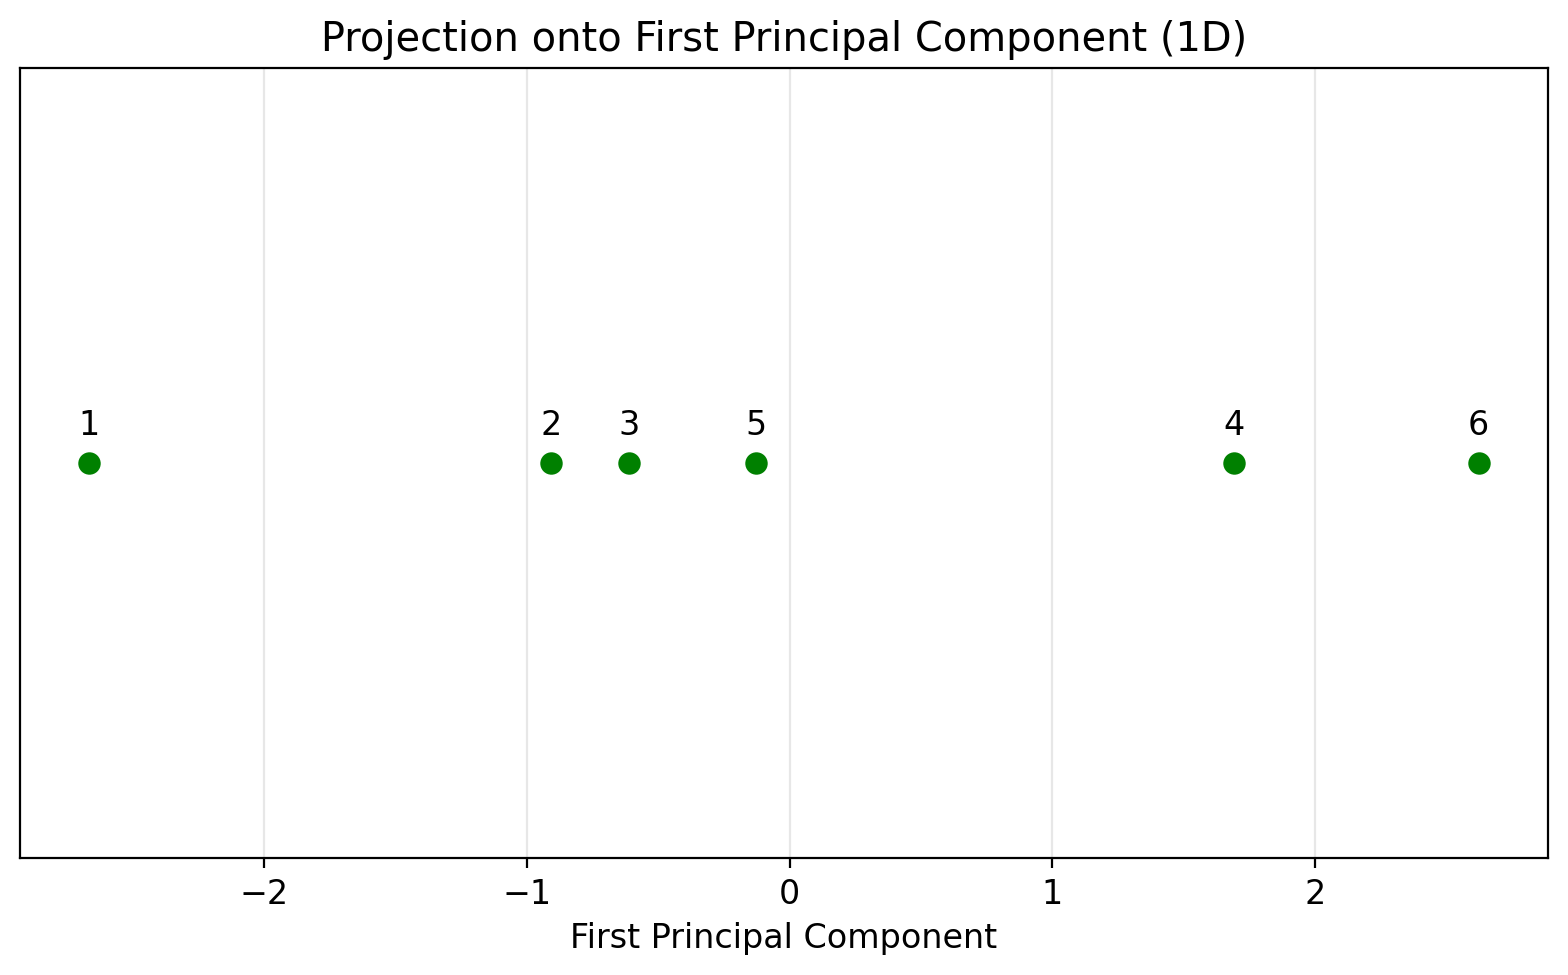

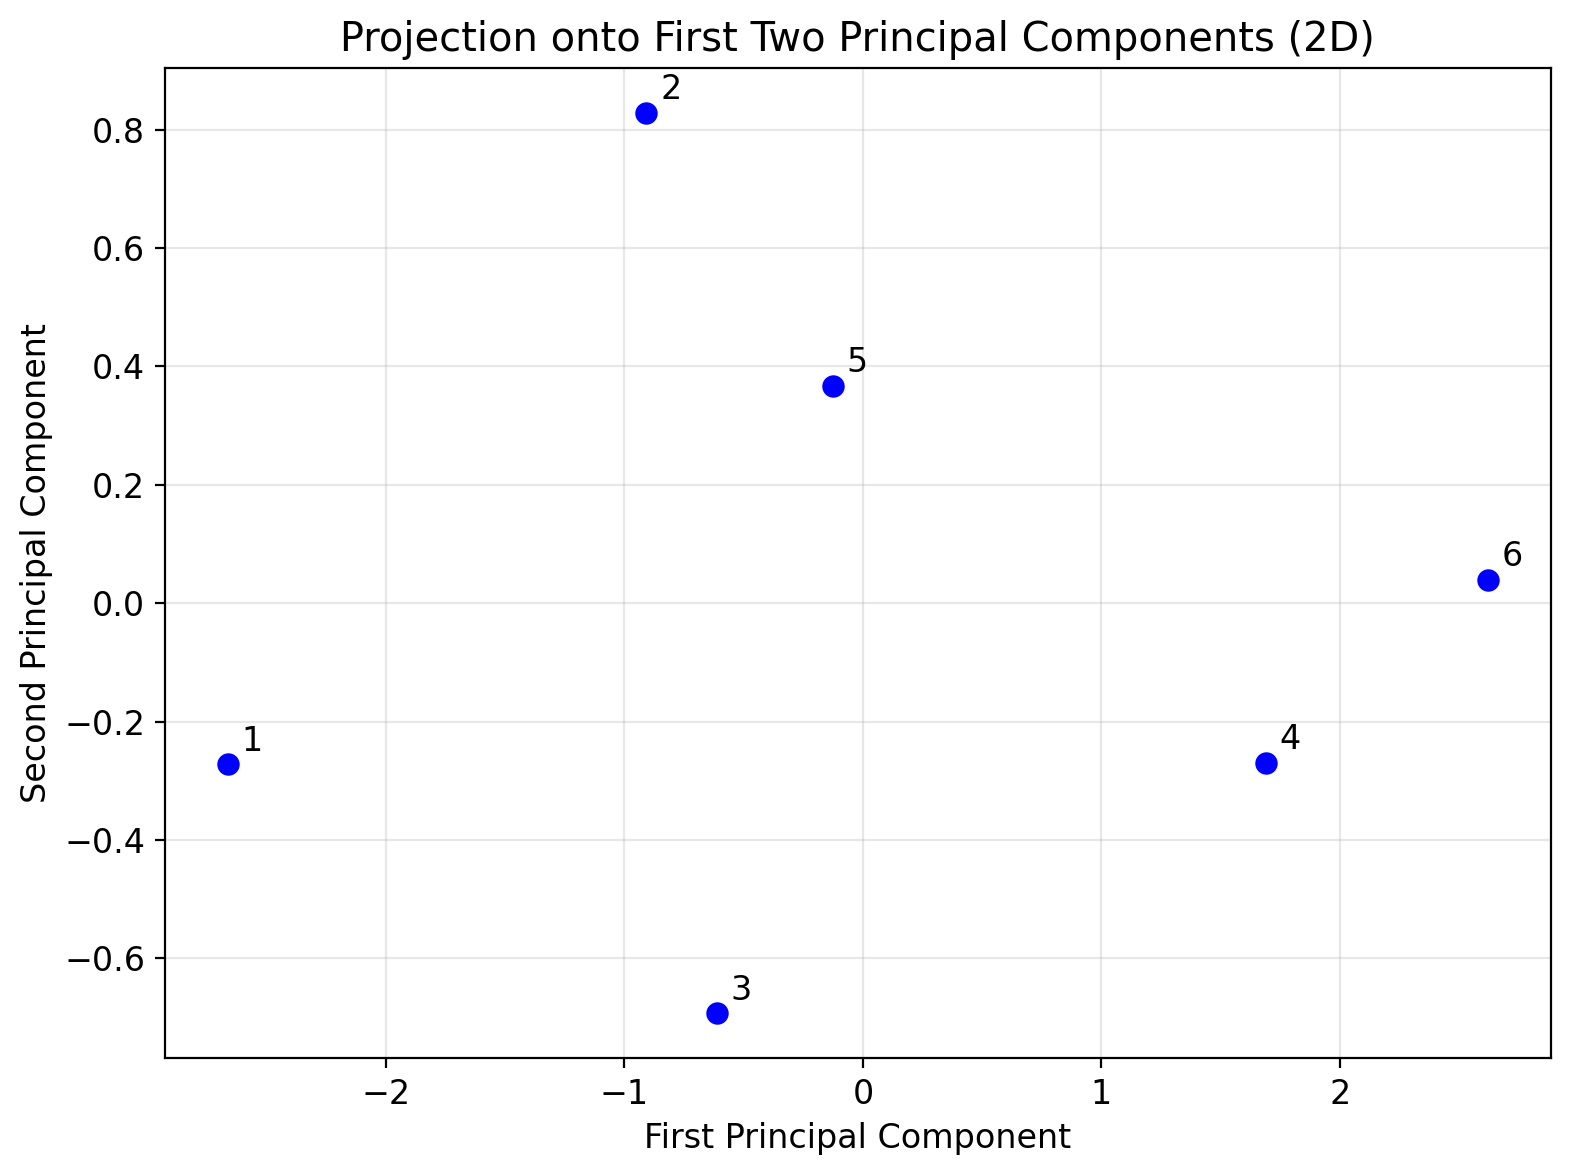

In [7]:
# Project onto 1D (first principal component)
proj_1d = project_data(data_std, eigenvectors, n_components=1)
plot_projection_1d(proj_1d, title="Projection onto First Principal Component (1D)")

# Project onto 2D (first two principal components)
proj_2d = project_data(data_std, eigenvectors, n_components=2)
plot_projection_2d(proj_2d, title="Projection onto First Two Principal Components (2D)")

## Verification with scikit‑learn PCA (optional)

To validate our implementation, we compare our results with scikit‑learn's `PCA` class. The projections should match (up to sign).

In [8]:
# Optional: Compare with sklearn
from sklearn.decomposition import PCA

pca_sklearn = PCA(n_components=2)
proj_sklearn = pca_sklearn.fit_transform(data_std)

print("Our projection (first 2 components):")
print(proj_2d)
print("\nScikit-learn projection:")
print(proj_sklearn)

# Note: signs may differ but the relative structure is the same.

Our projection (first 2 components):
[[-2.66418232 -0.27245688]
 [-0.90773937  0.82880456]
 [-0.61241675 -0.69307179]
 [ 1.69022883 -0.26948127]
 [-0.12729009  0.36647521]
 [ 2.6213997   0.03973017]]

Scikit-learn projection:
[[-2.66418232  0.27245688]
 [-0.90773937 -0.82880456]
 [-0.61241675  0.69307179]
 [ 1.69022883  0.26948127]
 [-0.12729009 -0.36647521]
 [ 2.6213997  -0.03973017]]


## Summary and Next Steps

**Accomplished in this notebook:**

- Implemented PCA from scratch using NumPy.
- Standardised the data (centering and scaling).
- Computed the covariance matrix.
- Performed eigendecomposition to obtain principal components.
- Projected data onto 1D and 2D subspaces.
- Visualised the projections with publication‑quality plots.
- Verified the implementation against scikit‑learn's PCA.

**Key insights:**

- The first principal component captures the maximum variance in the data.
- The explained variance ratio shows how much information each component retains.
- Projection reduces dimensionality while preserving the most important patterns.

**Suggested next steps (critical thinking):**

1. **Dimensionality reduction** – use PCA to reduce high‑dimensional data for visualisation or preprocessing before modelling.
2. **Interpretation** – examine the loadings (eigenvectors) to understand feature contributions.
3. **Inverse transform** – reconstruct original data from projections to measure reconstruction error.
4. **Kernel PCA** – explore non‑linear extensions for complex data structures.
5. **Sparse PCA** – implement variants that produce interpretable sparse components.

This notebook provides a deep understanding of PCA's internal mechanics, essential for any data scientist or machine learning practitioner.